In [ ]:
#!pip install hssm==0.3.0 numpy==2.0.2 --quiet
!pip install hssm==0.2.6 numpy==2.0.2 --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.2/222.2 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.2/109.2 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 828.2/828.2 kB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.8/394.8 kB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 98.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.2/82.2 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.0/120.0 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.3/150.3 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 5.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour i

In [ ]:
!pip install blackjax --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 61.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 75.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.5/85.5 MB 9.2 MB/s eta 0:00:00


In [ ]:
!pip install arviz-stats --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.8/183.8 kB 8.4 MB/s eta 0:00:00


In [ ]:
import hssm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

print(f"HSSM version: {hssm.__version__}")

sns.set(style="ticks", font_scale=1.2)
plt.rcParams["figure.dpi"] = 100


/usr/local/lib/python3.12/dist-packages/jaxlib/plugin_support.py:91: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.7.2 is installed, but it is not compatible with the installed jaxlib version 0.10.2, so it will not be used.
  warnings.warn(


HSSM version: 0.2.6


In [ ]:
from ssms.basic_simulators.simulator import simulator
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import expit  # sigmoid

# PARAMETROS GENERALES

V_BASE = 1.0    # drift rate --> COMO DE RAPIDO ACUMULAS EVIDENCIA
A      = 1.5    # threshold --> QUE TAN LEJOS ESTAN LOS DOS LIMITES
T      = 0.3    # non-decision time --> TIEMPO QUE NO ES DE DECISION
BIAS = 0.35     # SESGO DEL STARTING POINT --> este parametro si que es exclusivo del modelo A

N_SUBJ   = 25    # participantes
N_TRIALS = 1000  # trials por participante


In [ ]:
rows_A = [] # se crea una lista vacia donde se irsn guardando todos los trials simulados

# para cada participante
for subj in range(N_SUBJ):

    # como no todos los participantes son iguales --> hay que añadir variabilidad entre participantes (efectos aleatorios)
    v_subj = V_BASE + np.random.normal(0, 0.2) # añadimos un numero aleatorio con media 0 y std 0.2
    a_subj = A      + np.random.normal(0, 0.1) # lo mismo con el threshold

    # para cada trial
    for trial in range(N_TRIALS):

        # crearemos la evidencia sensorial del trial (rDV)
        rdv = np.random.normal(0, 0.3)
        v   = v_subj * rdv  # drift proporcional a la evidencia, es decir, "este participante, con esta evidencia sensorial en este trial concreto, acumula a esta velocidad"

        # nrep=0: starting point neutro
        out0  = simulator(theta=[v, a_subj, 0.5, T],
                          model="ddm", n_samples=1)
        rt0   = float(out0["rts"].flatten()[0]) # devuelve el tiempo de reaccion
        deci0 = 1 if int(out0["choices"].flatten()[0]) == 1 else 0 # devuelve la decision (1 = diagonal, 0 = cardinal)

        # nrep=1: starting point sesgado --> segun lo que ha decidido en nrep 0
        # z es el starting point
        # si ha decidido diagonal (1) → z se mueve hacia 1 (0.5 + BIAS) --> se hace 0.5 + x o 0.5 - x porque en z = 0.5 → estas justo en el centro
        # si ha decidido cardinal (0) → z se mueve hacia 0 (0.5 - BIAS)
        z_bias = 0.5 + BIAS if deci0 == 1 else 0.5 - BIAS

        out1  = simulator(theta=[v, a_subj, z_bias, T],
                          model="ddm", n_samples=1)
        rt1   = float(out1["rts"].flatten()[0]) # guardamos rt
        deci1 = 1 if int(out1["choices"].flatten()[0]) == 1 else 0 # guardamos la decision

        # guardar nrep=0
        rows_A.append({"subj": subj, "trial": trial, "nrep": 0,
                        "rdv": rdv, "deci": deci0, "deci_prev": np.nan,
                        "RT": rt0, "z_used": 0.5})
        # guardar nrep=1
        rows_A.append({"subj": subj, "trial": trial, "nrep": 1,
                        "rdv": rdv, "deci": deci1, "deci_prev": deci0,
                        "RT": rt1, "z_used": z_bias})

df_A = pd.DataFrame(rows_A)

df1_A = df_A[df_A["nrep"] == 1] # FILTRAMOS SOLO TRIALS NREP 1
p_rep = (df1_A["deci"] == df1_A["deci_prev"]).mean() # calculamos la probabilidad de repetir la decision
# si el modelo funciona bien, el valor deberia ser mayor a 0.5 ya que el starting point sesgado hace que sea mas probable acabar en el mismo limite que antes

print(f"MODELO A — Starting Point Bias")
print(f"  Trials simulados : {len(df_A)}")
print(f"  p(repetir)       : {p_rep:.3f}  (esperado > 0.5)")
print(f"  RT medio nrep=0  : {df_A[df_A.nrep==0]['RT'].mean():.3f} s")
print(f"  RT medio nrep=1  : {df_A[df_A.nrep==1]['RT'].mean():.3f} s")
print(f"  BIAS usado       : z = 0.5 ± {BIAS}")

MODELO A — Starting Point Bias
  Trials simulados : 50000
  p(repetir)       : 0.870  (esperado > 0.5)
  RT medio nrep=0  : 2.452 s
  RT medio nrep=1  : 1.362 s
  BIAS usado       : z = 0.5 ± 0.35


In [ ]:
BIAS_V = 0.5  # sesgo sobre el drift rate --> parametro exclusivo del modelo B

rows_B = []

# para cada participante
for subj in range(N_SUBJ):

    # como no todos los participantes son iguales --> hay que añadir variabilidad entre participantes (efectos aleatorios)
    v_subj = V_BASE + np.random.normal(0, 0.2)
    a_subj = A      + np.random.normal(0, 0.1)

    # para cada trial
    for trial in range(N_TRIALS):

        # crearemos la evidencia sensorial del trial (rDV)
        rdv = np.random.normal(0, 0.3)
        v   = v_subj * rdv  # drift proporcional a la evidencia

        # nrep=0: drift neutro
        out0  = simulator(theta=[v, a_subj, 0.5, T],
                          model="ddm", n_samples=1)
        rt0   = float(out0["rts"].flatten()[0]) # devolvemos rt y decision
        deci0 = 1 if int(out0["choices"].flatten()[0]) == 1 else 0

        # nrep=1: drift sesgado
        # si ha decidio diagonal (1) → drift se inclina hacia diagonal
        # si ha decidio cardinal (0) → drift se inclina hacia cardinal
        v_bias = v + BIAS_V if deci0 == 1 else v - BIAS_V # z no varia, se queda en 0.5 neutro

        out1  = simulator(theta=[v_bias, a_subj, 0.5, T],
                          model="ddm", n_samples=1)
        rt1   = float(out1["rts"].flatten()[0])
        deci1 = 1 if int(out1["choices"].flatten()[0]) == 1 else 0

        # guardar nrep=0
        rows_B.append({"subj": subj, "trial": trial, "nrep": 0,
                        "rdv": rdv, "deci": deci0, "deci_prev": np.nan,
                        "RT": rt0, "v_used": v})
        # guardar nrep=1
        rows_B.append({"subj": subj, "trial": trial, "nrep": 1,
                        "rdv": rdv, "deci": deci1, "deci_prev": deci0,
                        "RT": rt1, "v_used": v_bias})

df_B = pd.DataFrame(rows_B)

df1_B = df_B[df_B["nrep"] == 1]
p_rep_B = (df1_B["deci"] == df1_B["deci_prev"]).mean()

print(f"MODELO B — Drift Rate Bias")
print(f"  Trials simulados : {len(df_B)}")
print(f"  p(repetir)       : {p_rep_B:.3f}  (esperado > 0.5)")
print(f"  RT medio nrep=0  : {df_B[df_B.nrep==0]['RT'].mean():.3f} s")
print(f"  RT medio nrep=1  : {df_B[df_B.nrep==1]['RT'].mean():.3f} s")
print(f"  BIAS_V usado     : v ± {BIAS_V}")

print(f"\nComparativa:")
print(f"  p(repetir) MODELO A (z bias) : {p_rep:.3f}")
print(f"  p(repetir) MODELO B (v bias) : {p_rep_B:.3f}")


MODELO B — Drift Rate Bias
  Trials simulados : 50000
  p(repetir)       : 0.840  (esperado > 0.5)
  RT medio nrep=0  : 2.557 s
  RT medio nrep=1  : 2.158 s
  BIAS_V usado     : v ± 0.5

Comparativa:
  p(repetir) MODELO A (z bias) : 0.870
  p(repetir) MODELO B (v bias) : 0.840


In [ ]:
from scipy.stats import norm
from scipy.optimize import curve_fit

# DEFINIMOS LAS FUNCIONES PARA VISUALIZAR LOS DOS MODELOS

# convierte cualquier valos de evidenvia sensioral x en una probabilidad entre 0 y 1
# pse es el punto donde la curva cruza el 505
# slope es como de empinada es la curva
def sigmoid(x, pse, slope):
    return 1 / (1 + np.exp(-slope * (x - pse)))

# generamos 2 paneles para cada modelo
def plot_psychometric(df, title, ax_left, ax_right):
    colors = {0: "#e74c3c", 1: "#2ecc71"}
    labels = {0: "deci-1 = Cardinal", 1: "deci-1 = Diagonal"}
    rdv_bins    = np.linspace(-0.6, 0.6, 12)
    rdv_centers = (rdv_bins[:-1] + rdv_bins[1:]) / 2

    # left panel: nrep=0
    df0 = df[df["nrep"] == 0].copy()
    df0["rdv_bin"] = pd.cut(df0["rdv"], bins=rdv_bins, labels=rdv_centers)
    df0["rdv_bin"] = df0["rdv_bin"].astype(float)
    pmf0 = df0.groupby("rdv_bin")["deci"].mean().reset_index()

    ax_left.plot(pmf0["rdv_bin"], pmf0["deci"],
                 "o-", color="steelblue", linewidth=2, label="nrep=0")
    ax_left.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
    ax_left.axvline(0.0, color="gray", linestyle="--", linewidth=0.8)
    ax_left.set_xlabel("rDV (sensory evidence)")
    ax_left.set_ylabel("p(diagonal)")
    ax_left.set_title(f"{title}\nnrep=0 (first presentation)")
    ax_left.set_ylim(0, 1)

    # right panel: nrep=1 split by deci_prev
    df1 = df[df["nrep"] == 1].copy()
    df1["rdv_bin"] = pd.cut(df1["rdv"], bins=rdv_bins, labels=rdv_centers)
    df1["rdv_bin"] = df1["rdv_bin"].astype(float)

    for prev in [0, 1]:
        d   = df1[df1["deci_prev"] == prev]
        pmf = d.groupby("rdv_bin")["deci"].mean().reset_index()
        ax_right.plot(pmf["rdv_bin"], pmf["deci"],
                      "o-", color=colors[prev],
                      linewidth=2, label=labels[prev])

    ax_right.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
    ax_right.axvline(0.0, color="gray", linestyle="--", linewidth=0.8)
    ax_right.set_xlabel("rDV (sensory evidence)")
    ax_right.set_ylabel("p(diagonal)")
    ax_right.set_title(f"{title}\nnrep=1 (second presentation, by deci-1)")
    ax_right.set_ylim(0, 1)
    ax_right.legend(fontsize=9)

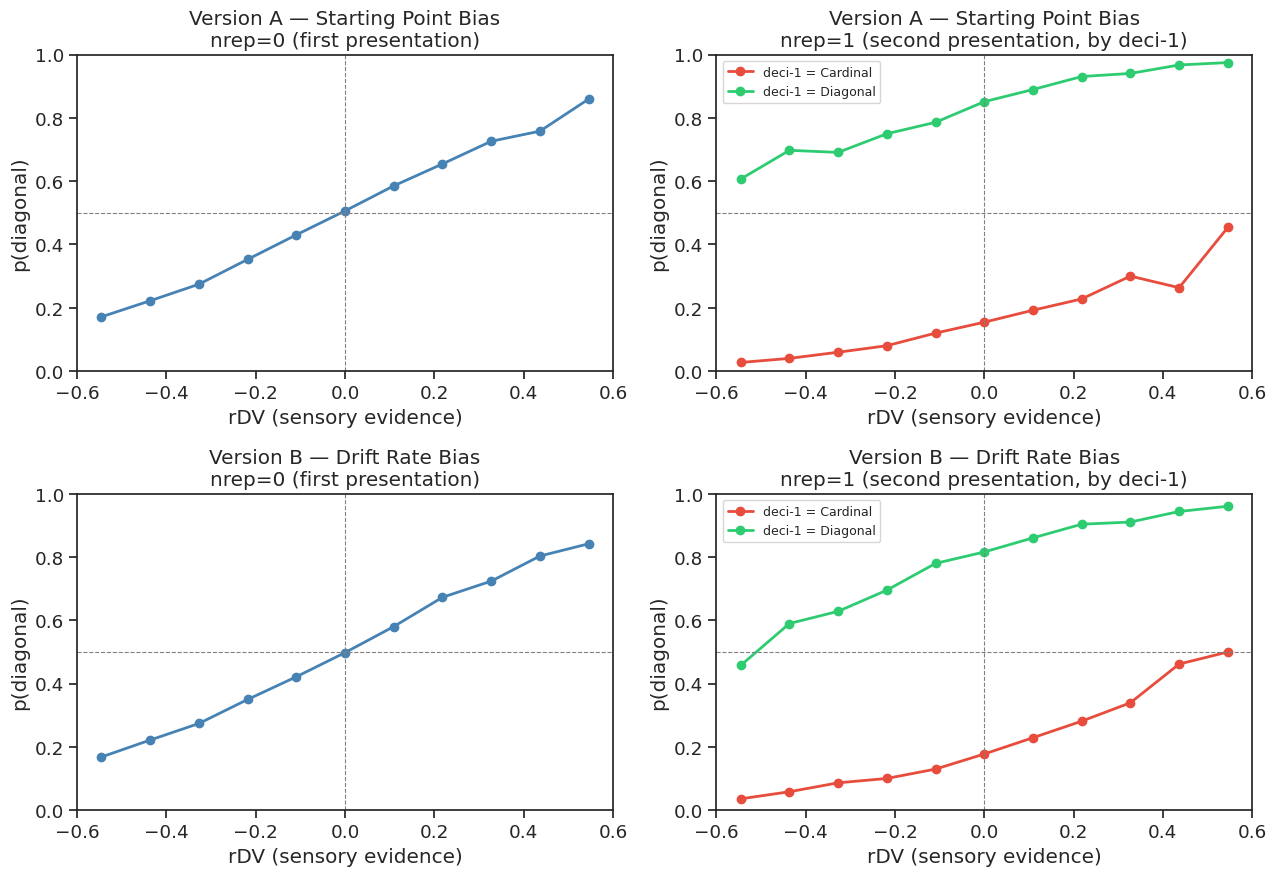

Estimated PSE (point where p(diagonal) = 0.5):
  Version A | deci-1=Cardinal → PSE = +0.683
  Version A | deci-1=Diagonal → PSE = -0.703
  Version B | deci-1=Cardinal → PSE = +0.530
  Version B | deci-1=Diagonal → PSE = -0.515


In [ ]:
# llamamos a las funciones definidas antes y creamos las dos figuras

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
plot_psychometric(df_A, "Version A — Starting Point Bias",
                  axes[0][0], axes[0][1])
plot_psychometric(df_B, "Version B — Drift Rate Bias",
                  axes[1][0], axes[1][1])
plt.tight_layout()
plt.show()

# calculamos el pse --> el valor de evidencia sensorial donde el participante responde "diagonal" el 50% de las veces
# es decir, el punto donde le cuesta igual decidir en un sentido que en otro
# si no hubiese sesgo, el pse = 0 (la curva cruza el 50% justo en el centro)
print("Estimated PSE (point where p(diagonal) = 0.5):")
for name, df_sim in [("Version A", df_A), ("Version B", df_B)]:
    df1 = df_sim[df_sim["nrep"] == 1].copy()
    df1["rdv_bin"] = pd.cut(df1["rdv"],
                             bins=np.linspace(-0.6, 0.6, 12),
                             labels=np.linspace(-0.6, 0.6, 12)[:-1] +
                                    np.diff(np.linspace(-0.6, 0.6, 12))/2)
    df1["rdv_bin"] = df1["rdv_bin"].astype(float)
    for prev in [0, 1]:
        d = df1[df1["deci_prev"] == prev]
        pmf = d.groupby("rdv_bin")["deci"].mean().reset_index().dropna()
        try:
            popt, _ = curve_fit(sigmoid, pmf["rdv_bin"], pmf["deci"],
                                 p0=[0, 5], maxfev=5000)
            print(f"  {name} | deci-1={'Cardinal' if prev==0 else 'Diagonal'}"
                  f" → PSE = {popt[0]:+.3f}")
        except:
            print(f"  {name} | deci-1={prev} → did not converge")

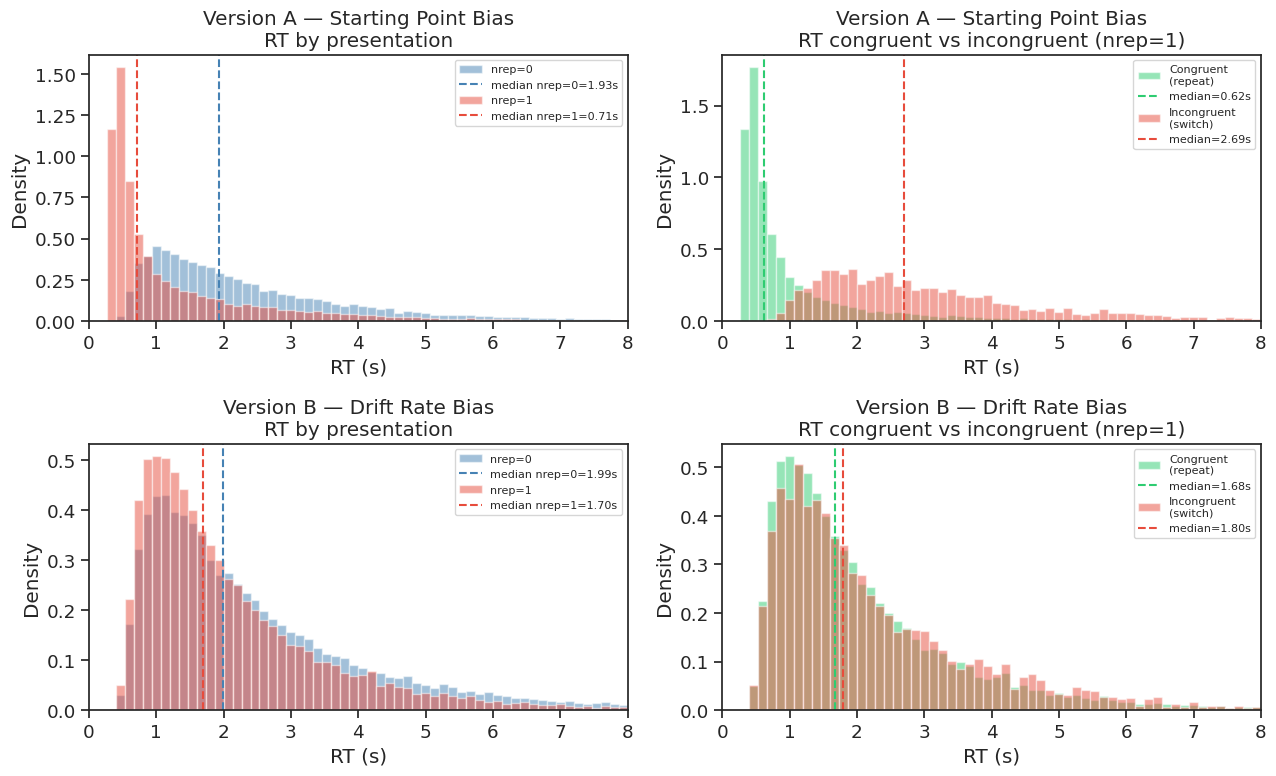

Median RT (seconds):

  Version A:
    nrep=0            : 1.933s
    nrep=1 congruent  : 0.617s  ← faster
    nrep=1 incongruent: 2.695s  ← slower
    Difference        : 2.078s

  Version B:
    nrep=0            : 1.986s
    nrep=1 congruent  : 1.678s  ← faster
    nrep=1 incongruent: 1.798s  ← slower
    Difference        : 0.120s


In [ ]:
# COMPARACION DE RTs ENTRE LOS DOS MODELOS

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for row, (name, df_sim) in enumerate([("Version A — Starting Point Bias", df_A),
                                       ("Version B — Drift Rate Bias",     df_B)]):

    # left panel: RT by nrep --> mostramos la distribucion de RTs en nrep0 y nrep1
    ax = axes[row][0]
    for nrep, color, label in [(0, "steelblue", "nrep=0"),
                                (1, "#e74c3c",  "nrep=1")]:
        d = df_sim[df_sim["nrep"] == nrep]["RT"]
        ax.hist(d, bins=60, alpha=0.5, color=color, label=label,
                density=True, range=(0, 8))
        ax.axvline(d.median(), color=color, linestyle="--",
                   linewidth=1.5, label=f"median {label}={d.median():.2f}s")
    ax.set_xlabel("RT (s)")
    ax.set_ylabel("Density")
    ax.set_title(f"{name}\nRT by presentation")
    ax.legend(fontsize=8)
    ax.set_xlim(0, 8)

    # right panel: RT on nrep=1 by congruence --> es decir, se analiza si tardas mas o menos en decidir cuando vas en contra de tu sesgo?
    # congruente = si decide diagonal y el sesgo tambien empuja hacia diagonal → todo va en la misma direccion → decide rapido
    # incongruente = si decide cardinal pero el sesgo empuja hacia diagonal → tarda mas en decidir → decide lento

    ax = axes[row][1]
    df1 = df_sim[df_sim["nrep"] == 1].copy()
    df1["congruent"] = (df1["deci"] == df1["deci_prev"]).map(
        {True: "Congruent\n(repeat)", False: "Incongruent\n(switch)"}
    )
    for cong, color in [("Congruent\n(repeat)",   "#2ecc71"),
                        ("Incongruent\n(switch)", "#e74c3c")]:
        d = df1[df1["congruent"] == cong]["RT"]
        ax.hist(d, bins=60, alpha=0.5, color=color, label=cong,
                density=True, range=(0, 8))
        ax.axvline(d.median(), color=color, linestyle="--",
                   linewidth=1.5, label=f"median={d.median():.2f}s")
    ax.set_xlabel("RT (s)")
    ax.set_ylabel("Density")
    ax.set_title(f"{name}\nRT congruent vs incongruent (nrep=1)")
    ax.legend(fontsize=8)
    ax.set_xlim(0, 8)

plt.tight_layout()
plt.show()


print("Median RT (seconds):")
for name, df_sim in [("Version A", df_A), ("Version B", df_B)]:
    df1 = df_sim[df_sim["nrep"] == 1].copy()
    df1["congruent"] = df1["deci"] == df1["deci_prev"]
    rt_cong   = df1[df1["congruent"]]["RT"].median()
    rt_incong = df1[~df1["congruent"]]["RT"].median()
    print(f"\n  {name}:")
    print(f"    nrep=0            : {df_sim[df_sim.nrep==0]['RT'].median():.3f}s")
    print(f"    nrep=1 congruent  : {rt_cong:.3f}s  ← faster")
    print(f"    nrep=1 incongruent: {rt_incong:.3f}s  ← slower")
    print(f"    Difference        : {rt_incong - rt_cong:.3f}s")

EN LOS PASOS DE ANTES, HEMOS SIMULADO DATOS, SIMPLEMENTE PARA VISUALIZAR LOS MODELOS Y ENTENDERLOS --> para el parameter recovery necesitamos un dataset mas pequeño para ver si funciona, porque es muy lento

In [ ]:
# PARAMETER RECOVERY MODELO A --> tenemos los datos simulados y sabemos que estan generados con BIAS = 0.35 — ese es el peso real que ya conoces
# entonces se los damos al HSSM y le preguntamos : cuanto BIAS ves en estos datos? si dice 0.35 quiere decir que es capaz de detectarlo bien, lo que significa, que funciona bien
# usamos un subconjunto pequeño para que sea rapido (5 participantes, 200 trials)

N_SUBJ_PR   = 5
N_TRIALS_PR = 200
np.random.seed(42)

rows_pr = []

# para cada participante
for subj in range(N_SUBJ_PR):

    # creamos la variabilidad de cada participante
    v_subj = V_BASE + np.random.normal(0, 0.2)
    a_subj = A      + np.random.normal(0, 0.1)

    # para cada trial
    for trial in range(N_TRIALS_PR):
        rdv = np.random.normal(0, 0.3) # crearemos la evidencia sensorial del trial (rDV)
        v   = v_subj * rdv # creamos el drift rate proporcional a la evidencia

        # nrep=0 sin sesgo
        out0  = simulator(theta=[v, a_subj, 0.5, T],
                          model="ddm", n_samples=1)
        rt0   = float(out0["rts"].flatten()[0])
        deci0 = int(out0["choices"].flatten()[0])  # {-1, 1}

        # nrep=1: starting point sesgado
        z_bias = 0.5 + BIAS if deci0 == 1 else 0.5 - BIAS
        out1   = simulator(theta=[v, a_subj, z_bias, T],
                           model="ddm", n_samples=1)
        rt1    = float(out1["rts"].flatten()[0])
        deci1  = int(out1["choices"].flatten()[0])  # {-1, 1}

        # z_cov: +1 si deci_prev=diagonal o -1 si cardinal
        # (la decisión en ssms ya viene en {-1, 1})
        z_cov = float(deci0)  # +1 o -1 directamente, HSSM usara esta variable para saber cual fue la decision anterior y estimar cuanto se desplaza el starting point

        rows_pr.append({
            "subj":     subj,
            "trial":    trial,
            "rt":       rt1,
            "response": deci1,   # {-1, 1} para HSSM
            "rdv":      rdv,
            "z_cov":    z_cov,   # covariable del starting point
            "deci_prev": deci0
        })

df_pr = pd.DataFrame(rows_pr)

# solo guardamos los trials de nrep 1 porque son los unicos que tienen decision previa

print(f"Datos para parameter recovery MODELO A :")
print(f"  Participantes  : {df_pr['subj'].nunique()}")
print(f"  Trials totales : {len(df_pr)}")
print(f"  response values: {sorted(df_pr['response'].unique())}")
print(f"  BIAS real      : z = 0.5 ± {BIAS}")
print()
print(df_pr[["subj","rdv","rt","response","z_cov"]].head(6))

Datos para parameter recovery MODELO A :
  Participantes  : 5
  Trials totales : 1000
  response values: [np.int64(-1), np.int64(1)]
  BIAS real      : z = 0.5 ± 0.35

   subj       rdv        rt  response  z_cov
0     0  0.194307  0.878422         1    1.0
1     0  0.456909  0.546624         1    1.0
2     0 -0.070246  2.093038         1   -1.0
3     0 -0.070241  1.471853         1   -1.0
4     0  0.473764  0.639895         1    1.0
5     0  0.230230  0.467253         1    1.0


In [ ]:
# definimos el modelo HSSM para el starting point bias
# ESTE MODELO ES EL QUE INTENTARA RECUPERAR EL BIAS

# HSSM es un tipo de DDM donde los parametros no son valores fijos, sino que dependen de covariables :
# v ~ rdv → el drift es proporcional a la evidencia sensorial
# z ~ z_cov → el starting point depende de la decision previa
# a = threshold, t = non decision time → constantes (sin covariables)

model_A = hssm.HSSM(
    data=df_pr,
    model="ddm",
    include=[
        {
            "name": "v",
            "formula": "v ~ rdv",
            "prior": {
                "Intercept": {"name": "Normal", "mu": 0, "sigma": 2},
                "rdv":       {"name": "Normal", "mu": 0, "sigma": 2}
            },
            "link": "identity"
        },
        {
            "name": "z",
            "formula": "z ~ z_cov",
            "prior": {
                "Intercept": {"name": "Normal", "mu": 0,    "sigma": 1},
                "z_cov":     {"name": "Normal", "mu": 0,    "sigma": 1}
            },
            "link": "logit"
        }
    ]
)

print(model_A)

Model initialized successfully.


INFO:hssm:Model initialized successfully.


Hierarchical Sequential Sampling Model
Model: ddm

Response variable: rt,response
Likelihood: analytical
Observations: 1000

Parameters:

v:
    Formula: v ~ rdv
    Priors:
        v_Intercept ~ Normal(mu: 0.0, sigma: 2.0)
        v_rdv ~ Normal(mu: 0.0, sigma: 2.0)
    Link: identity
    Explicit bounds: (-inf, inf)

a:
    Prior: HalfNormal(sigma: 2.0)
    Explicit bounds: (0.0, inf)

z:
    Formula: z ~ z_cov
    Priors:
        z_Intercept ~ Normal(mu: 0.0, sigma: 1.0)
        z_z_cov ~ Normal(mu: 0.0, sigma: 1.0)
    Link: logit
    Explicit bounds: (0.0, 1.0)

t:
    Prior: HalfNormal(sigma: 2.0)
    Explicit bounds: (0.0, inf)


Lapse probability: 0.05
Lapse distribution: Uniform(lower: 0.0, upper: 20.0)


In [ ]:
import pymc as pm
import arviz as az

# MCMC --> es el algoritmo que usa el modelo para estimar los parametros
# en vez de encontrar 1 unico valor para cada parametro, MCMC genera una distribucion de valores posibles para cada parametro
with model_A.pymc_model:
    trace_A = pm.sample(
        draws=1000, # guarda 1000 valores para cada parametro
        tune=1000, # numero de pasos que se descartan al principio
        chains=2, # numero de cadenas que se ejecutan en paralelo --> para verificar que llega a la misma conclusion
        target_accept=0.9,
    )

print("=" * 60)
print("PARAMETER RECOVERY — MODELO A (Starting Point Bias)")
print("=" * 60)

# z_z_cov → el BIAS estimado !!!!! que es lo que queremos recuperar
posterior = trace_A.posterior
for var in ["v_rdv", "z_Intercept", "z_z_cov"]:
    vals = posterior[var].values.flatten()
    print(f"{var}: mean={vals.mean():.3f}, sd={vals.std():.3f}, "
          f"94% CI=[{np.percentile(vals, 3):.3f}, {np.percentile(vals, 97):.3f}]")

print()
print(f"BIAS real introducido : {BIAS}")
print(f"z real para diagonal  : 0.5 + {BIAS} = {0.5 + BIAS}")
print(f"z real para cardinal  : 0.5 - {BIAS} = {0.5 - BIAS}")
print()
print("Lo que buscamos recuperar:")
print(f"  z_Intercept → debería ser ~0 (neutro cuando z_cov=0)")
print(f"  z_z_cov     → debería ser positivo (sesgo hacia diagonal)")

Output()

PARAMETER RECOVERY — MODELO A (Starting Point Bias)
v_rdv: mean=1.368, sd=0.150, 94% CI=[1.094, 1.654]
z_Intercept: mean=0.065, sd=0.029, 94% CI=[0.012, 0.122]
z_z_cov: mean=1.665, sd=0.047, 94% CI=[1.573, 1.756]

BIAS real introducido : 0.35
z real para diagonal  : 0.5 + 0.35 = 0.85
z real para cardinal  : 0.5 - 0.35 = 0.15000000000000002

Lo que buscamos recuperar:
  z_Intercept → debería ser ~0 (neutro cuando z_cov=0)
  z_z_cov     → debería ser positivo (sesgo hacia diagonal)


In [ ]:
# PARAMETER RECOVERY MODELO B

rows_prB = []

for subj in range(N_SUBJ_PR):
    v_subj = V_BASE + np.random.normal(0, 0.2)
    a_subj = A      + np.random.normal(0, 0.1)

    for trial in range(N_TRIALS_PR):
        rdv = np.random.normal(0, 0.3)
        v   = v_subj * rdv

        # nrep=0
        out0  = simulator(theta=[v, a_subj, 0.5, T],
                          model="ddm", n_samples=1)
        rt0   = float(out0["rts"].flatten()[0])
        deci0 = int(out0["choices"].flatten()[0])  # {-1, 1}

        # nrep=1 : drift rate sesgado
        v_bias = v + BIAS_V if deci0 == 1 else v - BIAS_V # el sesgo actua sobre z
        out1   = simulator(theta=[v_bias, a_subj, 0.5, T],
                           model="ddm", n_samples=1)
        rt1    = float(out1["rts"].flatten()[0])
        deci1  = int(out1["choices"].flatten()[0])  # {-1, 1}

        # v_cov: covariable del drift rate bias
        # +1 si deci_prev=diagonal, -1 si cardinal
        v_cov = float(deci0)

        rows_prB.append({
            "subj":     subj,
            "trial":    trial,
            "rt":       rt1,
            "response": deci1,
            "rdv":      rdv,
            "v_cov":    v_cov,  # covariable del drift bias
            "deci_prev": deci0
        })

df_prB = pd.DataFrame(rows_prB)

print(f"Datos MODELO B:")
print(f"  Trials totales : {len(df_prB)}")
print(f"  BIAS_V real    : v ± {BIAS_V}")
print(df_prB[["subj","rdv","rt","response","v_cov"]].head(6))

Datos MODELO B:
  Trials totales : 1000
  BIAS_V real    : v ± 0.5
   subj       rdv        rt  response  v_cov
0     0  0.622578  1.916190         1    1.0
1     0 -0.206756  0.958210        -1   -1.0
2     0  0.520789  6.077710         1    1.0
3     0  0.059373  2.706211        -1   -1.0
4     0 -0.195425  0.830761        -1   -1.0
5     0 -0.145166  0.632942        -1   -1.0


In [ ]:
# definimos el modelo HSSM para el  drift rate bias
# v ~ rdv + v_cov  → el drift depende de la evidencia Y de la decision previa
# z → constante (sin sesgo en el starting point)
# a, t → constantes

model_B = hssm.HSSM(
    data=df_prB,
    model="ddm",
    include=[
        {
            "name": "v",
            "formula": "v ~ rdv + v_cov",
            "prior": {
                "Intercept": {"name": "Normal", "mu": 0, "sigma": 2},
                "rdv":       {"name": "Normal", "mu": 0, "sigma": 2},
                "v_cov":     {"name": "Normal", "mu": 0, "sigma": 2}
            },
            "link": "identity"
        }
    ]
)

print(model_B)

Model initialized successfully.


INFO:hssm:Model initialized successfully.


Hierarchical Sequential Sampling Model
Model: ddm

Response variable: rt,response
Likelihood: analytical
Observations: 1000

Parameters:

v:
    Formula: v ~ rdv + v_cov
    Priors:
        v_Intercept ~ Normal(mu: 0.0, sigma: 2.0)
        v_rdv ~ Normal(mu: 0.0, sigma: 2.0)
        v_v_cov ~ Normal(mu: 0.0, sigma: 2.0)
    Link: identity
    Explicit bounds: (-inf, inf)

a:
    Prior: HalfNormal(sigma: 2.0)
    Explicit bounds: (0.0, inf)

z:
    Prior: Uniform(lower: 0.0, upper: 1.0)
    Explicit bounds: (0.0, 1.0)

t:
    Prior: HalfNormal(sigma: 2.0)
    Explicit bounds: (0.0, inf)


Lapse probability: 0.05
Lapse distribution: Uniform(lower: 0.0, upper: 20.0)


In [ ]:
# igual que antes pero para el modelo B
with model_B.pymc_model:
    trace_B = pm.sample(
        draws=1000,
        tune=1000,
        chains=2,
        target_accept=0.9,
    )

print("=" * 60)
print("PARAMETER RECOVERY — MODELO B (Drift Rate Bias)")
print("=" * 60)

posterior = trace_B.posterior
for var in ["v_Intercept", "v_rdv", "v_v_cov"]:
    vals = posterior[var].values.flatten()
    print(f"{var}: mean={vals.mean():.3f}, sd={vals.std():.3f}, "
          f"94% CI=[{np.percentile(vals, 3):.3f}, {np.percentile(vals, 97):.3f}]")

print()
print(f"BIAS_V real introducido: {BIAS_V}")
print()
print("Lo que buscamos recuperar:")
print(f"  v_v_cov → debería ser ~{BIAS_V} (el sesgo en el drift)")
print(f"  v_rdv   → debería ser positivo (evidencia sensorial)")

Output()

PARAMETER RECOVERY — MODELO B (Drift Rate Bias)
v_Intercept: mean=0.061, sd=0.033, 94% CI=[0.001, 0.124]
v_rdv: mean=1.005, sd=0.100, 94% CI=[0.821, 1.194]
v_v_cov: mean=0.572, sd=0.027, 94% CI=[0.522, 0.622]

BIAS_V real introducido: 0.5

Lo que buscamos recuperar:
  v_v_cov → debería ser ~0.5 (el sesgo en el drift)
  v_rdv   → debería ser positivo (evidencia sensorial)


In [ ]:
# CARGAR EL DATASET DE NUESTRO EXPERIMENTO

df_real = pd.read_csv("CJ_EEG_clean.csv")

# preprocesamiento
df_real["cond"]    = df_real["cond"].replace({-1: 0})
df_real["correct"] = df_real["correct"].replace({-1: 0})
df_real = df_real.sort_values(
    ["subj", "nblock", "ntrial", "nrep"]
).reset_index(drop=True)

# filtro RT (media + 4sd por participante)
def RT_filter(x, sd=4):
    return x[x["RT"] < x["RT"].mean() + sd * x["RT"].std()]

df_real = df_real.groupby(
    "npar", group_keys=False
).apply(RT_filter, sd=4).reset_index(drop=True)

# nos quedamos solo con nrep=1 (donde existe decision previa)
df_hssm = df_real[df_real["nrep"] == 1].copy()

# preparamos las variables para el HSSM
# HSSM necesita {-1, 1} asi que hacemos deci=1 → diagonal → +1 y deci=0 → cardinal → -1

df_hssm["response"] = df_hssm["deci"].map({1: 1, 0: -1})

df_hssm["rt"] = df_hssm["RT"].copy()

# rDV estandarizado por participante, asi todos quedan en la misma escala
df_hssm["rdv_z"] = df_hssm.groupby("subj")["rDV"].transform(
    lambda x: (x - x.mean()) / x.std()
)

# covariable de sesgo = decision previa --> +1 si deci-1=diagonal, -1 si cardinal
# hssm necesita la covariable centrada en 0
df_hssm["bias_cov"] = df_hssm["deci-1"].map({1: 1.0, 0: -1.0})

# eliminar NaN
df_hssm = df_hssm.dropna(
    subset=["rt", "response", "rdv_z", "bias_cov"]
).reset_index(drop=True)

print(f"Dataset real preparado para HSSM:")
print(f"  Participantes  : {df_hssm['subj'].nunique()}")
print(f"  Trials totales : {len(df_hssm)}")
print(f"  response values: {sorted(df_hssm['response'].unique())}")
print(f"  rt rango       : {df_hssm['rt'].min():.2f} - {df_hssm['rt'].max():.2f}s")
print()
print(df_hssm[["subj","rdv_z","rt","response","bias_cov"]].head(6))

Dataset real preparado para HSSM:
  Participantes  : 25
  Trials totales : 2170
  response values: [np.int64(-1), np.int64(1)]
  rt rango       : 0.44 - 5.29s

  subj     rdv_z        rt  response  bias_cov
0  s01 -1.243072  1.498671        -1      -1.0
1  s01 -0.629775  1.000176         1       1.0
2  s01  0.629506  0.881386         1       1.0
3  s01  0.632066  1.193105         1       1.0
4  s01  0.268435  1.096550         1       1.0
5  s01 -0.537508  1.231761         1       1.0


/tmp/ipykernel_1681/2358835785.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(RT_filter, sd=4).reset_index(drop=True)


In [ ]:
# MODELO A SOBRE LOS DATOS REALES
# hay evidencia de starting point bias en los datos reales?

# DEFINIMOS EL HSSM  PARA PODER APLICAR A LOS DATOS REALES
model_real_A = hssm.HSSM(
    data=df_hssm,
    model="ddm",
    include=[
        {
            "name": "v",
            "formula": "v ~ rdv_z",
            "prior": {
                "Intercept": {"name": "Normal", "mu": 0, "sigma": 2},
                "rdv_z":     {"name": "Normal", "mu": 0, "sigma": 2}
            },
            "link": "identity"
        },
        {
            "name": "z",
            "formula": "z ~ bias_cov",
            "prior": {
                "Intercept": {"name": "Normal", "mu": 0, "sigma": 1},
                "bias_cov":  {"name": "Normal", "mu": 0, "sigma": 1}
            },
            "link": "logit"
        }
    ]
)

print(model_real_A)

Model initialized successfully.


INFO:hssm:Model initialized successfully.


Hierarchical Sequential Sampling Model
Model: ddm

Response variable: rt,response
Likelihood: analytical
Observations: 2170

Parameters:

v:
    Formula: v ~ rdv_z
    Priors:
        v_Intercept ~ Normal(mu: 0.0, sigma: 2.0)
        v_rdv_z ~ Normal(mu: 0.0, sigma: 2.0)
    Link: identity
    Explicit bounds: (-inf, inf)

a:
    Prior: HalfNormal(sigma: 2.0)
    Explicit bounds: (0.0, inf)

z:
    Formula: z ~ bias_cov
    Priors:
        z_Intercept ~ Normal(mu: 0.0, sigma: 1.0)
        z_bias_cov ~ Normal(mu: 0.0, sigma: 1.0)
    Link: logit
    Explicit bounds: (0.0, 1.0)

t:
    Prior: HalfNormal(sigma: 2.0)
    Explicit bounds: (0.0, inf)


Lapse probability: 0.05
Lapse distribution: Uniform(lower: 0.0, upper: 20.0)


In [ ]:
# MODELO B SOBRE LOS DATOS REALES
# hay evidencia de drift rate bias en los datos reales?

# DEFINIMOS EL HSSM  PARA PODER APLICAR A LOS DATOS REALES
model_real_B = hssm.HSSM(
    data=df_hssm,
    model="ddm",
    include=[
        {
            "name": "v",
            "formula": "v ~ rdv_z + bias_cov",
            "prior": {
                "Intercept": {"name": "Normal", "mu": 0, "sigma": 2},
                "rdv_z":     {"name": "Normal", "mu": 0, "sigma": 2},
                "bias_cov":  {"name": "Normal", "mu": 0, "sigma": 2}
            },
            "link": "identity"
        }
    ]
)

print(model_real_B)

Model initialized successfully.


INFO:hssm:Model initialized successfully.


Hierarchical Sequential Sampling Model
Model: ddm

Response variable: rt,response
Likelihood: analytical
Observations: 2170

Parameters:

v:
    Formula: v ~ rdv_z + bias_cov
    Priors:
        v_Intercept ~ Normal(mu: 0.0, sigma: 2.0)
        v_rdv_z ~ Normal(mu: 0.0, sigma: 2.0)
        v_bias_cov ~ Normal(mu: 0.0, sigma: 2.0)
    Link: identity
    Explicit bounds: (-inf, inf)

a:
    Prior: HalfNormal(sigma: 2.0)
    Explicit bounds: (0.0, inf)

z:
    Prior: Uniform(lower: 0.0, upper: 1.0)
    Explicit bounds: (0.0, 1.0)

t:
    Prior: HalfNormal(sigma: 2.0)
    Explicit bounds: (0.0, inf)


Lapse probability: 0.05
Lapse distribution: Uniform(lower: 0.0, upper: 20.0)


Fitting Model A (Starting Point Bias)...


Output()


Fitting Model B (Drift Rate Bias)...


Output()


RESULTS — Real data CJ_EEG

Model A — Starting Point Bias:
  z_Intercept: mean=-0.027, sd=0.031, 94% CI=[-0.085, 0.033]
  z_bias_cov: mean=0.416, sd=0.030, 94% CI=[0.359, 0.469]

Model B — Drift Rate Bias:
  v_Intercept: mean=0.212, sd=0.033, 94% CI=[0.149, 0.277]
  v_rdv_z: mean=0.364, sd=0.030, 94% CI=[0.307, 0.423]
  v_bias_cov: mean=0.772, sd=0.031, 94% CI=[0.715, 0.832]


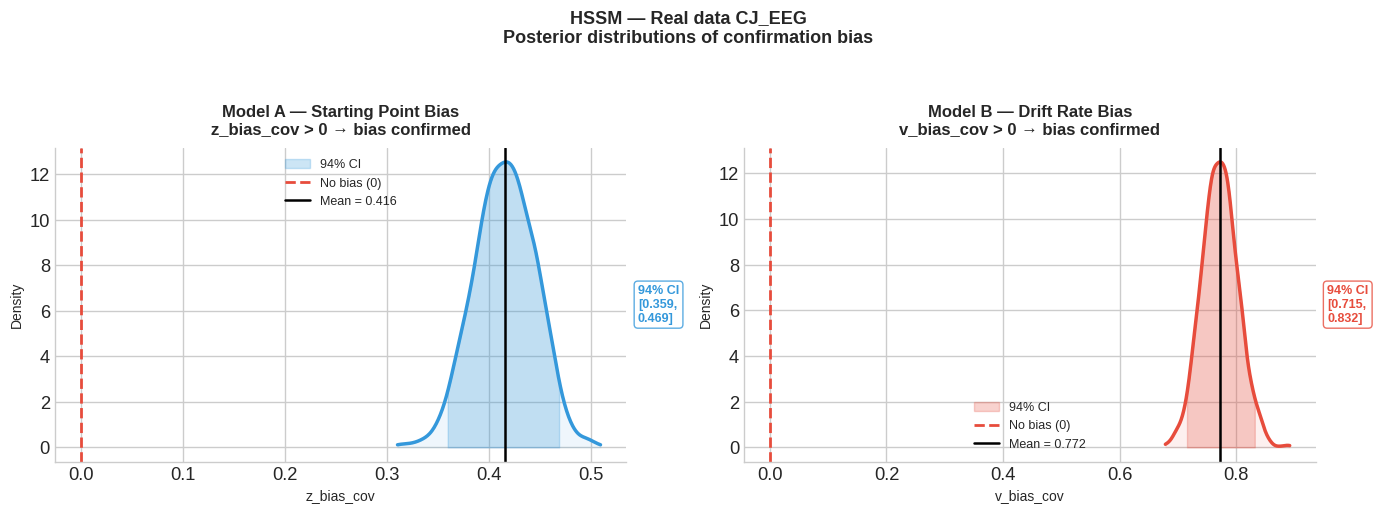

In [ ]:
# EJECUTAMOS EL MODELO A
print("Fitting Model A (Starting Point Bias)...")
with model_real_A.pymc_model:
    trace_real_A = pm.sample(
        draws=1000, tune=1000, chains=2, target_accept=0.9
    )

# EJECUTAMOS EL MODELO B
print("\nFitting Model B (Drift Rate Bias)...")
with model_real_B.pymc_model:
    trace_real_B = pm.sample(
        draws=1000, tune=1000, chains=2, target_accept=0.9
    )

print("\n" + "=" * 60)
print("RESULTS — Real data CJ_EEG")
print("=" * 60)

print("\nModel A — Starting Point Bias:")
for var in ["z_Intercept", "z_bias_cov"]:
    vals = trace_real_A.posterior[var].values.flatten()
    print(f"  {var}: mean={vals.mean():.3f}, sd={vals.std():.3f}, "
          f"94% CI=[{np.percentile(vals, 3):.3f}, {np.percentile(vals, 97):.3f}]")

print("\nModel B — Drift Rate Bias:")
for var in ["v_Intercept", "v_rdv_z", "v_bias_cov"]:
    vals = trace_real_B.posterior[var].values.flatten()
    print(f"  {var}: mean={vals.mean():.3f}, sd={vals.std():.3f}, "
          f"94% CI=[{np.percentile(vals, 3):.3f}, {np.percentile(vals, 97):.3f}]")



from scipy.stats import gaussian_kde

plt.style.use("seaborn-v0_8-whitegrid")
COLOR_A    = "#3498db"
COLOR_B    = "#e74c3c"
COLOR_ZERO = "#e74c3c"

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("white")




vals_A  = trace_real_A.posterior["z_bias_cov"].values.flatten()
kde_A   = gaussian_kde(vals_A)
x_A     = np.linspace(vals_A.min(), vals_A.max(), 300)
ci_lo_A = np.percentile(vals_A, 3)
ci_hi_A = np.percentile(vals_A, 97)

axes[0].plot(x_A, kde_A(x_A), color=COLOR_A, linewidth=2.5)
axes[0].fill_between(x_A, kde_A(x_A),
                     where=(x_A >= ci_lo_A) & (x_A <= ci_hi_A),
                     color=COLOR_A, alpha=0.25, label="94% CI")
axes[0].fill_between(x_A, kde_A(x_A), color=COLOR_A, alpha=0.08)
axes[0].axvline(0, color=COLOR_ZERO, linestyle="--", linewidth=2, label="No bias (0)")
axes[0].axvline(vals_A.mean(), color="black", linestyle="-", linewidth=1.8,
                label=f"Mean = {vals_A.mean():.3f}")
axes[0].set_title("Model A — Starting Point Bias\nz_bias_cov > 0 → bias confirmed",
                  fontsize=12, fontweight="bold", pad=10)
axes[0].set_xlabel("z_bias_cov", fontsize=10)
axes[0].set_ylabel("Density", fontsize=10)
axes[0].legend(fontsize=9)
axes[0].spines[["top", "right"]].set_visible(False)

# CI justo a la derecha del gráfico
axes[0].text(1.02, 0.5,
             f"94% CI\n[{ci_lo_A:.3f},\n{ci_hi_A:.3f}]",
             transform=axes[0].transAxes,
             fontsize=9, color=COLOR_A, fontweight="bold",
             va="center", ha="left",
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                       edgecolor=COLOR_A, alpha=0.8))




vals_B  = trace_real_B.posterior["v_bias_cov"].values.flatten()
kde_B   = gaussian_kde(vals_B)
x_B     = np.linspace(vals_B.min(), vals_B.max(), 300)
ci_lo_B = np.percentile(vals_B, 3)
ci_hi_B = np.percentile(vals_B, 97)

axes[1].plot(x_B, kde_B(x_B), color=COLOR_B, linewidth=2.5)
axes[1].fill_between(x_B, kde_B(x_B),
                     where=(x_B >= ci_lo_B) & (x_B <= ci_hi_B),
                     color=COLOR_B, alpha=0.25, label="94% CI")
axes[1].fill_between(x_B, kde_B(x_B), color=COLOR_B, alpha=0.08)
axes[1].axvline(0, color=COLOR_ZERO, linestyle="--", linewidth=2, label="No bias (0)")
axes[1].axvline(vals_B.mean(), color="black", linestyle="-", linewidth=1.8,
                label=f"Mean = {vals_B.mean():.3f}")
axes[1].set_title("Model B — Drift Rate Bias\nv_bias_cov > 0 → bias confirmed",
                  fontsize=12, fontweight="bold", pad=10)
axes[1].set_xlabel("v_bias_cov", fontsize=10)
axes[1].set_ylabel("Density", fontsize=10)
axes[1].legend(fontsize=9)
axes[1].spines[["top", "right"]].set_visible(False)

# CI
axes[1].text(1.02, 0.5,
             f"94% CI\n[{ci_lo_B:.3f},\n{ci_hi_B:.3f}]",
             transform=axes[1].transAxes,
             fontsize=9, color=COLOR_B, fontweight="bold",
             va="center", ha="left",
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                       edgecolor=COLOR_B, alpha=0.8))

plt.suptitle("HSSM — Real data CJ_EEG\nPosterior distributions of confirmation bias",
             fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig("hssm_posterior_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

Los parametros clave que nos interesan son:

z_bias_cov → cuanto desplaza la decision previa el
starting point en tus participantes?

v_bias_cov → cuanto distorsiona la decision previa el drift rate en tus participantes?

In [ ]:
# GUARDAMOS LOS TRACES
import arviz as az
from google.colab import files

trace_real_A.to_netcdf("trace_real_A.nc")
trace_real_B.to_netcdf("trace_real_B.nc")

files.download("trace_real_A.nc")
files.download("trace_real_B.nc")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

MODEL COMPARISON — Real data CJ_EEG

Model A — Starting Point Bias:
  z_bias_cov: mean=0.416, sd=0.030
  94% CI = [0.359, 0.469]
  → Bias confirmed: YES ✓

Model B — Drift Rate Bias:
  v_bias_cov: mean=0.772, sd=0.031
  94% CI = [0.715, 0.832]
  → Bias confirmed: YES ✓


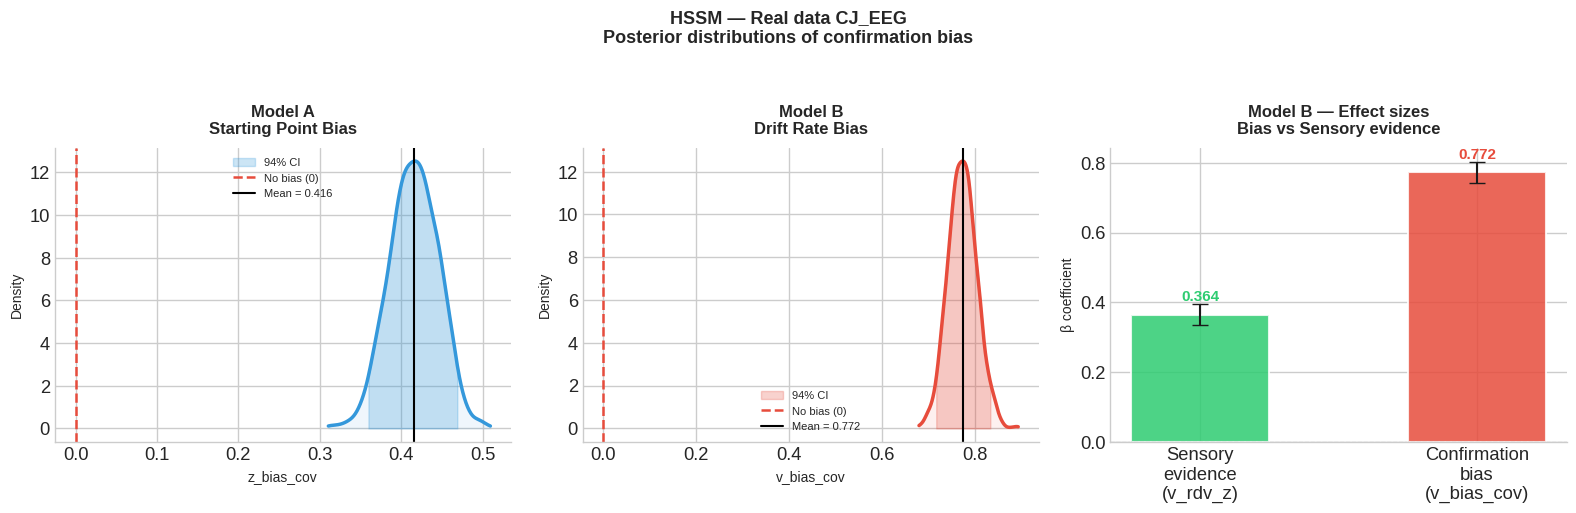

In [ ]:
# COMPARACION DE MODELOS
# comparamos los modelos mediante los coeficientes de sesgo estimados
print("=" * 60)
print("MODEL COMPARISON — Real data CJ_EEG")
print("=" * 60)

# extraer parmetros clave
z_bias = trace_real_A.posterior["z_bias_cov"].values.flatten()
v_bias = trace_real_B.posterior["v_bias_cov"].values.flatten()
v_rdv  = trace_real_B.posterior["v_rdv_z"].values.flatten()

print(f"\nModel A — Starting Point Bias:")
print(f"  z_bias_cov: mean={z_bias.mean():.3f}, sd={z_bias.std():.3f}")
print(f"  94% CI = [{np.percentile(z_bias, 3):.3f}, {np.percentile(z_bias, 97):.3f}]")
print(f"  → Bias confirmed: {'YES ✓' if np.percentile(z_bias, 3) > 0 else 'NO'}")

print(f"\nModel B — Drift Rate Bias:")
print(f"  v_bias_cov: mean={v_bias.mean():.3f}, sd={v_bias.std():.3f}")
print(f"  94% CI = [{np.percentile(v_bias, 3):.3f}, {np.percentile(v_bias, 97):.3f}]")
print(f"  → Bias confirmed: {'YES ✓' if np.percentile(v_bias, 3) > 0 else 'NO'}")



plt.style.use("seaborn-v0_8-whitegrid")
COLOR_A   = "#3498db"
COLOR_B   = "#e74c3c"
COLOR_RDV = "#2ecc71"
COLOR_ZERO = "#e74c3c"

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor("white")



from scipy.stats import gaussian_kde

kde_A = gaussian_kde(z_bias)
x_A   = np.linspace(z_bias.min(), z_bias.max(), 300)
ci_lo_A, ci_hi_A = np.percentile(z_bias, 3), np.percentile(z_bias, 97)

axes[0].plot(x_A, kde_A(x_A), color=COLOR_A, linewidth=2.5)
axes[0].fill_between(x_A, kde_A(x_A),
                     where=(x_A >= ci_lo_A) & (x_A <= ci_hi_A),
                     color=COLOR_A, alpha=0.25, label="94% CI")
axes[0].fill_between(x_A, kde_A(x_A), color=COLOR_A, alpha=0.08)
axes[0].axvline(0, color=COLOR_ZERO, linestyle="--", linewidth=1.8, label="No bias (0)")
axes[0].axvline(z_bias.mean(), color="black", linestyle="-", linewidth=1.5,
                label=f"Mean = {z_bias.mean():.3f}")
axes[0].set_title("Model A\nStarting Point Bias", fontsize=12, fontweight="bold", pad=10)
axes[0].set_xlabel("z_bias_cov", fontsize=10)
axes[0].set_ylabel("Density", fontsize=10)
axes[0].legend(fontsize=8)
axes[0].spines[["top", "right"]].set_visible(False)



kde_B = gaussian_kde(v_bias)
x_B   = np.linspace(v_bias.min(), v_bias.max(), 300)
ci_lo_B, ci_hi_B = np.percentile(v_bias, 3), np.percentile(v_bias, 97)

axes[1].plot(x_B, kde_B(x_B), color=COLOR_B, linewidth=2.5)
axes[1].fill_between(x_B, kde_B(x_B),
                     where=(x_B >= ci_lo_B) & (x_B <= ci_hi_B),
                     color=COLOR_B, alpha=0.25, label="94% CI")
axes[1].fill_between(x_B, kde_B(x_B), color=COLOR_B, alpha=0.08)
axes[1].axvline(0, color=COLOR_ZERO, linestyle="--", linewidth=1.8, label="No bias (0)")
axes[1].axvline(v_bias.mean(), color="black", linestyle="-", linewidth=1.5,
                label=f"Mean = {v_bias.mean():.3f}")
axes[1].set_title("Model B\nDrift Rate Bias", fontsize=12, fontweight="bold", pad=10)
axes[1].set_xlabel("v_bias_cov", fontsize=10)
axes[1].set_ylabel("Density", fontsize=10)
axes[1].legend(fontsize=8)
axes[1].spines[["top", "right"]].set_visible(False)


params = ["Sensory\nevidence\n(v_rdv_z)", "Confirmation\nbias\n(v_bias_cov)"]
vals   = [v_rdv.mean(), v_bias.mean()]
errs   = [v_rdv.std(),  v_bias.std()]
colors = [COLOR_RDV, COLOR_B]

bars = axes[2].bar(params, vals, yerr=errs, color=colors,
                   capsize=6, alpha=0.85, edgecolor="white",
                   linewidth=1.5, width=0.5)
axes[2].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[2].set_ylabel("β coefficient", fontsize=10)
axes[2].set_title("Model B — Effect sizes\nBias vs Sensory evidence",
                  fontsize=12, fontweight="bold", pad=10)
axes[2].spines[["top", "right"]].set_visible(False)

for i, (v, e) in enumerate(zip(vals, errs)):
    axes[2].text(i, v + e + 0.01, f"{v:.3f}",
                 ha="center", fontsize=11, fontweight="bold",
                 color=colors[i])

plt.suptitle("HSSM — Real data CJ_EEG\nPosterior distributions of confirmation bias",
             fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig("hssm_resultados_finales.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
import arviz as az
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.special import expit
import warnings

warnings.filterwarnings("ignore")

sns.set(font_scale=1.0, style="ticks")
plt.rcParams["figure.dpi"] = 120

trace_A = az.from_netcdf("trace_real_A.nc")  # Starting point bias
trace_B = az.from_netcdf("trace_real_B.nc")  # Drift-rate bias

print("Modelo A variables:", list(trace_A.posterior.data_vars))
print("Modelo B variables:", list(trace_B.posterior.data_vars))

Modelo A variables: ['a', 't', 'v', 'v_Intercept', 'v_rdv_z', 'z', 'z_Intercept', 'z_bias_cov']
Modelo B variables: ['a', 't', 'v', 'v_Intercept', 'v_bias_cov', 'v_rdv_z', 'z']


In [ ]:
# COMPARACION FORMAL DE MODELOS (WAIC / LOO)

import pymc as pm
import arviz as az

# Calculamos la log-verosimilitud punto por punto (trial por trial) a partir de los traces
with model_real_A.pymc_model:
    pm.compute_log_likelihood(trace_real_A)

with model_real_B.pymc_model:
    pm.compute_log_likelihood(trace_real_B)

# Comparamos los dos modelos

comparison = None
for ic in ["loo", "waic"]:
    try:
        comparison = az.compare(
            {
                "Model A (Starting Point Bias)": trace_real_A,
                "Model B (Drift Rate Bias)":     trace_real_B,
            },
            ic=ic
        )
        print("=" * 60)
        print(f"MODEL COMPARISON ({ic.upper()})")
        print("=" * 60)
        print(comparison)
        break
    except Exception as e:
        print(f"az.compare() con ic='{ic}' ha fallado: {e}")

Output()

Output()

MODEL COMPARISON (LOO)
                               rank     elpd_loo      p_loo   elpd_diff  \
Model B (Drift Rate Bias)         0 -2297.832746   6.979389    0.000000   
Model A (Starting Point Bias)     1 -2539.527200  10.558500  241.694454   

                                 weight         se        dse  warning scale  
Model B (Drift Rate Bias)      0.946914  54.095634   0.000000     True   log  
Model A (Starting Point Bias)  0.053086  48.735578  22.358457     True   log  


In [ ]:
# PRECISION PREDICTIVA (% de aciertos) -- que modelo predice mejor las decisiones reales

import numpy as np

def ddm_choice_prob(v, a, z):

    v = np.asarray(v, dtype=float)
    z = np.asarray(z, dtype=float)
    a = float(a)

    # evitamos division por cero cuando v es casi 0
    p = np.where(
        np.abs(v) < 1e-8,
        z,
        (1 - np.exp(-2 * v * z * a)) / (1 - np.exp(-2 * v * a))
    )
    return np.clip(p, 1e-6, 1 - 1e-6)

# MODELO A: medias del posterior
post_A  = trace_real_A.posterior
vA_int  = post_A["v_Intercept"].values.mean()
vA_rdv  = post_A["v_rdv_z"].values.mean()
zA_int  = post_A["z_Intercept"].values.mean()
zA_bias = post_A["z_bias_cov"].values.mean()
aA      = post_A["a"].values.mean()
tA      = post_A["t"].values.mean()

v_pred_A  = vA_int + vA_rdv * df_hssm["rdv_z"].values
z_pred_A  = 1 / (1 + np.exp(-(zA_int + zA_bias * df_hssm["bias_cov"].values)))
p_upper_A = ddm_choice_prob(v_pred_A, aA, z_pred_A)
pred_A    = np.where(p_upper_A >= 0.5, 1, -1)
acc_A     = (pred_A == df_hssm["response"].values).mean()

# MODELO B: medias del posterior
post_B  = trace_real_B.posterior
vB_int  = post_B["v_Intercept"].values.mean()
vB_rdv  = post_B["v_rdv_z"].values.mean()
vB_bias = post_B["v_bias_cov"].values.mean()
zB      = post_B["z"].values.mean()
aB      = post_B["a"].values.mean()
tB      = post_B["t"].values.mean()

v_pred_B  = vB_int + vB_rdv * df_hssm["rdv_z"].values + vB_bias * df_hssm["bias_cov"].values
p_upper_B = ddm_choice_prob(v_pred_B, aB, zB)
pred_B    = np.where(p_upper_B >= 0.5, 1, -1)
acc_B     = (pred_B == df_hssm["response"].values).mean()

print("=" * 60)
print("PRECISION PREDICTIVA -- decisiones reales vs predichas")
print("=" * 60)
print(f"Modelo A (Starting Point Bias) : {acc_A*100:.1f}% de aciertos")
print(f"Modelo B (Drift Rate Bias)      : {acc_B*100:.1f}% de aciertos")
print(f"Diferencia                      : {(acc_B-acc_A)*100:+.1f} puntos porcentuales")

PRECISION PREDICTIVA -- decisiones reales vs predichas
Modelo A (Starting Point Bias) : 82.5% de aciertos
Modelo B (Drift Rate Bias)      : 84.8% de aciertos
Diferencia                      : +2.4 puntos porcentuales


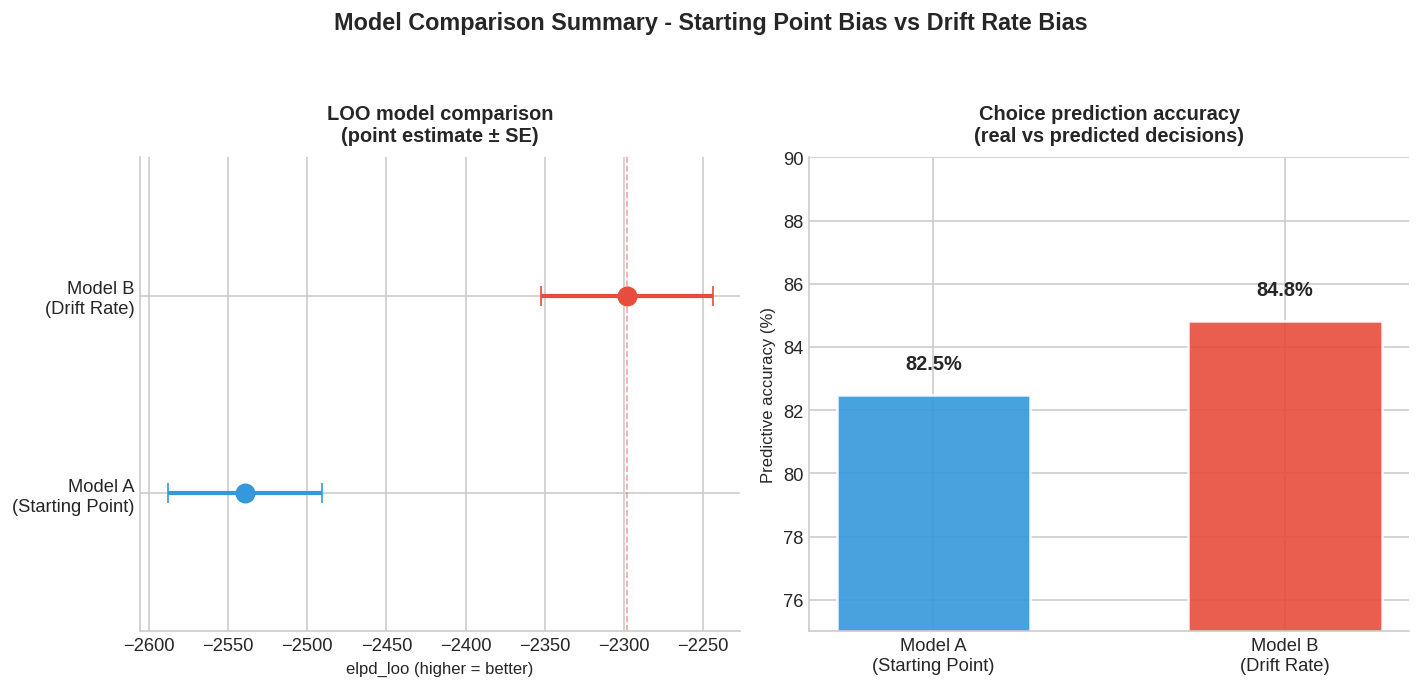

In [ ]:

import matplotlib.pyplot as plt
import numpy as np

COLOR_A = "#3498db"
COLOR_B = "#e74c3c"

model_A = {"label": "Model A\n(Starting Point)", "elpd": -2539.443595, "se": 48.744242, "acc": acc_A * 100, "color": COLOR_A, "y": 0}
model_B = {"label": "Model B\n(Drift Rate)",      "elpd": -2298.159622, "se": 54.092422, "acc": acc_B * 100, "color": COLOR_B, "y": 1}
model_list = [model_A, model_B]

plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
fig.patch.set_facecolor("white")



for m in model_list:
    axes[0].errorbar(m["elpd"], m["y"], xerr=m["se"], fmt="o", color=m["color"], ecolor=m["color"],
                      elinewidth=2.5, capsize=6, markersize=11, zorder=3)

axes[0].axvline(model_B["elpd"], color=COLOR_B, linestyle="--", linewidth=1, alpha=0.5, zorder=1)
axes[0].set_yticks([m["y"] for m in model_list])
axes[0].set_yticklabels([m["label"] for m in model_list])
axes[0].set_xlabel("elpd_loo (higher = better)", fontsize=10)
axes[0].set_title("LOO model comparison\n(point estimate ± SE)", fontsize=12, fontweight="bold", pad=10)
axes[0].set_ylim(-0.7, 1.7)
axes[0].spines[["top", "right"]].set_visible(False)




labels      = [m["label"] for m in model_list]
accuracies  = [m["acc"] for m in model_list]
colors_bar  = [m["color"] for m in model_list]
bars = axes[1].bar(labels, accuracies, color=colors_bar, width=0.55,
                    edgecolor="white", linewidth=1.5, alpha=0.9)
for bar, acc in zip(bars, accuracies):
    axes[1].text(bar.get_x() + bar.get_width()/2, acc + 0.8, f"{acc:.1f}%",
                 ha="center", fontsize=12, fontweight="bold")
axes[1].set_ylim(75, 90)
axes[1].set_ylabel("Predictive accuracy (%)", fontsize=10)
axes[1].set_title("Choice prediction accuracy\n(real vs predicted decisions)",
                   fontsize=12, fontweight="bold", pad=10)
axes[1].spines[["top", "right"]].set_visible(False)

plt.suptitle("Model Comparison Summary - Starting Point Bias vs Drift Rate Bias",
             fontsize=14, fontweight="bold", y=1.04)
plt.tight_layout()
plt.savefig("model_comparison_summary.png", dpi=150, bbox_inches="tight")
plt.show()